# Delhivery: ETA, Delay, and Delay Propagation Prediction — Multi-Tree Models

This notebook merges three Delhivery repositories and fixes several important methodological risks:

- aggregate up to the `trip_uuid` level before predicting ETA;
- use `trip_end_time - trip_start_time` as the ground truth for the final duration;
- preserve the external time-based `training/test` split and create an additional validation split inside training;
- use only features guaranteed to be available at departure time;
- do not select the model using the final test set;
- sort checkpoints by `cutoff_timestamp`, not by `actual_time`;
- drop stages with `segment_osrm_time <= 0`;
- drop `total_stages` and other future-looking features;
- evaluate propagation at one checkpoint per trip;
- keep ETA and delay always consistent: `predicted_delay = predicted_duration - osrm_time`;
- compare several tree-based models: **Decision Tree, Random Forest, Extra Trees, AdaBoost, and XGBoost**;
- explain predictions with SHAP.

> **Definition:** `osrm_time` is a routing baseline/proxy schedule, not the official delivery SLA. `actual_eta` is taken directly from `trip_end_time`.


## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Loading](#2-data-loading)
3. [Data Quality Assessment](#3-data-quality-assessment)
4. [Preprocessing](#4-preprocessing)
5. [Aggregation: Segment → Leg → Trip](#5-aggregation-segment--leg--trip)
6. [EDA](#6-eda)
7. [Feature Engineering](#7-feature-engineering)
8. [Data Splitting and Leakage Prevention](#8-data-splitting-and-leakage-prevention)
9. [ETA Regression Model](#9-eta-regression-model)
10. [Delay Magnitude Model](#10-delay-magnitude-model)
11. [Severe Delay Probability Model](#11-severe-delay-probability-model)
12. [Delay Propagation Model](#12-delay-propagation-model)
13. [Explainability with SHAP](#13-explainability-with-shap)
14. [Single-Shipment Prediction Example](#14-single-shipment-prediction-example)
15. [Model Export and Conclusion](#15-model-export-and-conclusion)


## 1. Environment Setup


Required packages:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib
```

The notebook uses the full dataset by default. `FAST_MODE=True` can be enabled to reduce the number of trees for quick trials.


In [3]:
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    root_mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from xgboost import XGBRegressor, XGBClassifier
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
FAST_MODE = False
DELAY_THRESHOLD_MINUTES = 120
N_JOBS = 2


## 2. Data Loading


On Kaggle, the dataset is loaded directly from the `/kaggle/input` path. The cell below prioritizes the user-supplied path and falls back to local paths when running locally.


In [4]:
KAGGLE_DATA_PATH = Path(
    '/kaggle/input/datasets/santanukundu/delhivery-dataset/delhivery_data.csv'
)


def find_data_path(filename='delhivery_data.csv'):
    candidates = [
        KAGGLE_DATA_PATH,
        Path('/kaggle/input/delhivery-dataset') / filename,
        Path(filename),
        Path('data') / filename,
        Path('Delhivery-Logistics-Shipment-Data-Analysis-main') / filename,
        Path('repo2') / 'Delhivery-Logistics-Shipment-Data-Analysis-main' / filename,
    ]

    for path in candidates:
        if path.exists():
            return path.resolve()

    matches = list(Path.cwd().glob(f'**/{filename}'))
    if matches:
        return matches[0].resolve()

    checked = '\n'.join(f'- {path}' for path in candidates)
    raise FileNotFoundError(
        f'Không tìm thấy {filename}. Các đường dẫn đã kiểm tra:\n{checked}'
    )


DATA_PATH = find_data_path()
print(f'Data path: {DATA_PATH}')

raw_df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns')
display(raw_df.head())


Data path: /kaggle/input/datasets/santanukundu/delhivery-dataset/delhivery_data.csv
Raw shape: 144,867 rows × 24 columns


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,9,2018-09-20 04:27:55,10.436,14.000,11.000,11.965,1.273,14.000,11.000,11.965,1.273
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,18,2018-09-20 04:17:55,18.937,24.000,20.000,21.724,1.200,10.000,9.000,9.759,1.111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,27,2018-09-20 04:01:19.505586,27.637,40.000,28.000,32.539,1.429,16.000,7.000,10.815,2.286
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,36,2018-09-20 03:39:57,36.118,62.000,40.000,45.562,1.550,21.000,12.000,13.022,1.750
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,False,39,2018-09-20 03:33:55,39.386,68.000,44.000,54.218,1.545,6.000,5.000,3.915,1.200


### Condensed Data Dictionary

| Category | Main Fields | Purpose |
|---|---|---|
| ID | `trip_uuid`, `route_schedule_uuid` | Identify the trip and route schedule |
| Route | `source_*`, `destination_*`, `route_type` | Geographic and transport-type features |
| Ground truth | `od_start_time`, `od_end_time` | Compute the actual duration and final ETA |
| Plan | `osrm_time`, `osrm_distance`, `segment_osrm_*` | Routing baseline used to compute the proxy delay |
| Dynamic actuals | `segment_actual_time`, `cutoff_timestamp` | Only usable after the checkpoint has occurred |
| Audit | `actual_time`, `factor`, `segment_factor` | Not used as a start-of-trip target/feature because of leakage risk or because it does not represent the full elapsed time |


## 3. Data Quality Assessment


In [5]:
quality_summary = pd.DataFrame({
    'dtype': raw_df.dtypes.astype(str),
    'missing_count': raw_df.isna().sum(),
    'missing_pct': raw_df.isna().mean().mul(100),
    'n_unique': raw_df.nunique(dropna=False),
}).sort_values('missing_pct', ascending=False)

display(quality_summary)

print(f'Exact duplicate rows: {raw_df.duplicated().sum():,}')
print(f'Unique trips: {raw_df["trip_uuid"].nunique():,}')
print(f'Negative segment_actual_time rows: {(raw_df["segment_actual_time"] < 0).sum():,}')
print(f'Non-positive segment_osrm_time rows: {(raw_df["segment_osrm_time"] <= 0).sum():,}')

,dtype,missing_count,missing_pct,n_unique
source_name,object,293,0.202,1499
destination_name,object,261,0.180,1469
route_schedule_uuid,object,0,0.000,1504
data,object,0,0.000,2
route_type,object,0,0.000,2
trip_uuid,object,0,0.000,14817
source_center,object,0,0.000,1508
trip_creation_time,object,0,0.000,14817
destination_center,object,0,0.000,1481
od_start_time,object,0,0.000,26369


Exact duplicate rows: 0
Unique trips: 14,817
Negative segment_actual_time rows: 21
Non-positive segment_osrm_time rows: 2,347


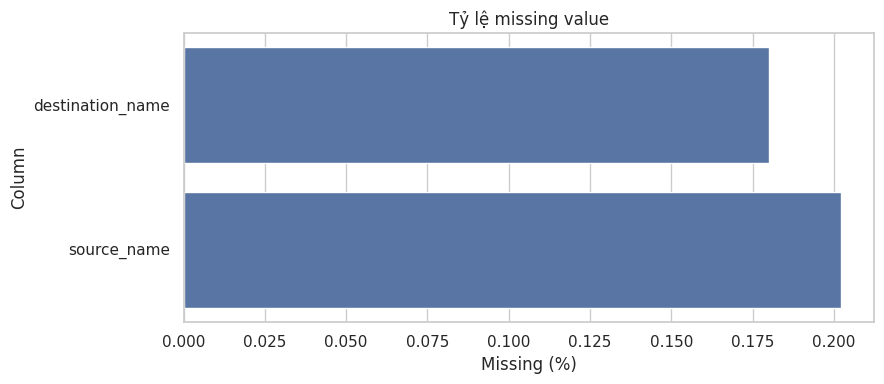

In [6]:
missing = quality_summary.query('missing_count > 0').sort_values('missing_pct')
if not missing.empty:
    plt.figure(figsize=(9, 4))
    sns.barplot(data=missing.reset_index(), x='missing_pct', y='index', color='C0')
    plt.xlabel('Missing (%)')
    plt.ylabel('Column')
    plt.title('Tỷ lệ missing value')
    plt.tight_layout()
    plt.show()
else:
    print('Không có missing value.')

## 4. Preprocessing


Processing principles:

- Do not modify the original dataframe directly; work on a copy.
- Convert columns to the correct datetime type.
- Fill missing location names with the most common/first name within the same `center`, then fall back to the center code.
- Split `city` and `state` out of the location name.
- Keep anomaly flags instead of removing all logistics outliers, since long trips or large delays may be genuine data.


In [7]:
df = raw_df.copy()
df = df.drop_duplicates().reset_index(drop=True)

DATETIME_COLUMNS = [
    'trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp'
]


def parse_mixed_datetime(series):
    """Parse timestamp có/không có microseconds mà không làm mất dữ liệu hợp lệ."""
    try:
        return pd.to_datetime(series, format='mixed', errors='coerce')
    except TypeError:
        return pd.to_datetime(series, errors='coerce')


for col in DATETIME_COLUMNS:
    df[col] = parse_mixed_datetime(df[col])

df['source_name'] = (
    df['source_name']
      .fillna(df.groupby('source_center')['source_name'].transform('first'))
      .fillna(df['source_center'])
)
df['destination_name'] = (
    df['destination_name']
      .fillna(df.groupby('destination_center')['destination_name'].transform('first'))
      .fillna(df['destination_center'])
)


def extract_city(series):
    return series.astype(str).str.split('_').str[0].str.strip()


def extract_state(series):
    return (
        series.astype(str)
              .str.extract(r'\(([^()]*)\)\s*$', expand=False)
              .fillna('Unknown')
              .str.strip()
    )


df['source_city'] = extract_city(df['source_name'])
df['destination_city'] = extract_city(df['destination_name'])
df['source_state'] = extract_state(df['source_name'])
df['destination_state'] = extract_state(df['destination_name'])

df['negative_segment_time_flag'] = (df['segment_actual_time'] < 0).astype(int)
df['zero_segment_plan_flag'] = (df['segment_osrm_time'] <= 0).astype(int)
df['_row_order'] = np.arange(len(df))

print('Remaining missing values:')
display(df.isna().sum()[df.isna().sum() > 0])
print(f"Missing cutoff_timestamp after mixed parsing: {df['cutoff_timestamp'].isna().sum():,}")
display(df.head())

Remaining missing values:


Series([], dtype: int64)

Missing cutoff_timestamp after mixed parsing: 0


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,source_city,destination_city,source_state,destination_state,negative_segment_time_flag,zero_segment_plan_flag,_row_order
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,9,2018-09-20 04:27:55.000000,10.436,14.000,11.000,11.965,1.273,14.000,11.000,11.965,1.273,Anand,Khambhat,Gujarat,Gujarat,0,0,0
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,18,2018-09-20 04:17:55.000000,18.937,24.000,20.000,21.724,1.200,10.000,9.000,9.759,1.111,Anand,Khambhat,Gujarat,Gujarat,0,0,1
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,27,2018-09-20 04:01:19.505586,27.637,40.000,28.000,32.539,1.429,16.000,7.000,10.815,2.286,Anand,Khambhat,Gujarat,Gujarat,0,0,2
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,True,36,2018-09-20 03:39:57.000000,36.118,62.000,40.000,45.562,1.550,21.000,12.000,13.022,1.750,Anand,Khambhat,Gujarat,Gujarat,0,0,3
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.000,False,39,2018-09-20 03:33:55.000000,39.386,68.000,44.000,54.218,1.545,6.000,5.000,3.915,1.200,Anand,Khambhat,Gujarat,Gujarat,0,0,4


## 5. Aggregation: Segment → Leg → Trip


The raw dataset has multiple checkpoints for the same leg and multiple legs for the same trip. Training directly on individual rows could let checkpoints from the same trip fall into both train and test, artificially inflating the metric.

Aggregation pipeline:

1. **Checkpoint row**: a dynamic observation recorded during the journey.
2. **Leg**: rows sharing `trip_uuid + source + destination + od_start_time`.
3. **Trip**: a single row for each `trip_uuid`.

Checkpoints are sorted by `cutoff_timestamp`. Cumulative fields at the leg level use `max`; incremental fields use `sum`. The final ground truth is not taken from `actual_time`, but is computed from the trip's start/end timestamps.


In [8]:
df_sorted = df.sort_values(
    ['trip_uuid', 'od_start_time', 'cutoff_timestamp', '_row_order'],
    na_position='last',
).copy()

leg_keys = ['trip_uuid', 'source_center', 'destination_center', 'od_start_time']

leg_df = df_sorted.groupby(leg_keys, as_index=False).agg(
    data=('data', 'first'),
    route_schedule_uuid=('route_schedule_uuid', 'first'),
    route_type=('route_type', 'first'),
    trip_creation_time=('trip_creation_time', 'first'),
    source_name=('source_name', 'first'),
    destination_name=('destination_name', 'last'),
    source_city=('source_city', 'first'),
    destination_city=('destination_city', 'last'),
    source_state=('source_state', 'first'),
    destination_state=('destination_state', 'last'),
    od_end_time=('od_end_time', 'max'),
    start_scan_to_end_scan=('start_scan_to_end_scan', 'max'),
    actual_distance_to_destination=('actual_distance_to_destination', 'max'),
    actual_time=('actual_time', 'max'),
    osrm_time=('osrm_time', 'max'),
    osrm_distance=('osrm_distance', 'max'),
    segment_actual_time=('segment_actual_time', 'sum'),
    segment_osrm_time=('segment_osrm_time', 'sum'),
    segment_osrm_distance=('segment_osrm_distance', 'sum'),
    checkpoint_count=('trip_uuid', 'size'),
    cutoff_rate=('is_cutoff', 'mean'),
    anomaly_count=('negative_segment_time_flag', 'sum'),
    zero_plan_count=('zero_segment_plan_flag', 'sum'),
)

leg_df = leg_df.sort_values(['trip_uuid', 'od_start_time']).reset_index(drop=True)
print(f'Leg-level shape: {leg_df.shape}')
display(leg_df.head())

Leg-level shape: (26369, 27)


,trip_uuid,source_center,destination_center,od_start_time,data,route_schedule_uuid,route_type,trip_creation_time,source_name,destination_name,source_city,destination_city,source_state,destination_state,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,checkpoint_count,cutoff_rate,anomaly_count,zero_plan_count
0,trip-153671041653548748,IND462022AAA,IND209304AAA,2018-09-12 00:00:16.535741,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,2018-09-12 00:00:16.535741,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),Bhopal,Kanpur,Madhya Pradesh,Uttar Pradesh,2018-09-12 16:39:46.858469,999.000,440.974,830.000,394.000,544.803,820.000,474.000,649.853,21,0.952,0,0
1,trip-153671041653548748,IND209304AAA,IND000000ACB,2018-09-12 16:39:46.858469,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,2018-09-12 00:00:16.535741,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),Kanpur,Gurgaon,Uttar Pradesh,Haryana,2018-09-13 13:40:23.123744,"1,260.000",383.759,732.000,349.000,446.550,728.000,534.000,670.620,18,0.944,0,0
2,trip-153671042288605164,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,2018-09-12 00:00:22.886430,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),Tumkur,Doddablpur,Karnataka,Karnataka,2018-09-12 02:03:09.655591,122.000,48.543,96.000,42.000,56.912,95.000,39.000,55.990,6,0.833,0,0
3,trip-153671042288605164,IND561203AAB,IND562101AAA,2018-09-12 02:03:09.655591,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,2018-09-12 00:00:22.886430,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),Doddablpur,Chikblapur,Karnataka,Karnataka,2018-09-12 03:01:59.598855,58.000,24.644,47.000,26.000,28.199,46.000,26.000,28.200,3,0.667,0,0
4,trip-153671043369099517,IND562132AAA,IND000000ACB,2018-09-12 00:00:33.691250,training,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,2018-09-12 00:00:33.691250,Bangalore_Nelmngla_H (Karnataka),Gurgaon_Bilaspur_HB (Haryana),Bangalore,Gurgaon,Karnataka,Haryana,2018-09-14 03:40:17.106733,"3,099.000","1,689.965","2,736.000","1,529.000","2,090.874","2,700.000","1,710.000","2,227.527",77,0.987,0,0


In [9]:
trip_df = leg_df.groupby('trip_uuid', as_index=False).agg(
    data=('data', 'first'),
    route_schedule_uuid=('route_schedule_uuid', 'first'),
    route_type=('route_type', 'first'),
    trip_creation_time=('trip_creation_time', 'first'),
    source_center=('source_center', 'first'),
    destination_center=('destination_center', 'last'),
    source_name=('source_name', 'first'),
    destination_name=('destination_name', 'last'),
    source_city=('source_city', 'first'),
    destination_city=('destination_city', 'last'),
    source_state=('source_state', 'first'),
    destination_state=('destination_state', 'last'),
    trip_start_time=('od_start_time', 'min'),
    trip_end_time=('od_end_time', 'max'),
    leg_count=('trip_uuid', 'size'),
    checkpoint_count=('checkpoint_count', 'sum'),
    start_scan_to_end_scan=('start_scan_to_end_scan', 'sum'),
    actual_distance_to_destination=('actual_distance_to_destination', 'sum'),
    actual_time=('actual_time', 'sum'),
    osrm_time=('osrm_time', 'sum'),
    osrm_distance=('osrm_distance', 'sum'),
    segment_actual_time=('segment_actual_time', 'sum'),
    segment_osrm_time=('segment_osrm_time', 'sum'),
    segment_osrm_distance=('segment_osrm_distance', 'sum'),
    cutoff_rate=('cutoff_rate', 'mean'),
    anomaly_count=('anomaly_count', 'sum'),
    zero_plan_count=('zero_plan_count', 'sum'),
)

trip_df['trip_duration_minutes'] = (
    trip_df['trip_end_time'] - trip_df['trip_start_time']
).dt.total_seconds() / 60

trip_df = trip_df.query(
    'trip_duration_minutes > 0 and osrm_time > 0 and osrm_distance > 0'
).copy()
trip_df = trip_df.sort_values('trip_creation_time').reset_index(drop=True)

print(f'Trip-level shape: {trip_df.shape}')
print(f'Unique trip_uuid after aggregation: {trip_df.trip_uuid.nunique():,}')
display(trip_df.head())

Trip-level shape: (14817, 29)
Unique trip_uuid after aggregation: 14,817


,trip_uuid,data,route_schedule_uuid,route_type,trip_creation_time,source_center,destination_center,source_name,destination_name,source_city,destination_city,source_state,destination_state,trip_start_time,trip_end_time,leg_count,checkpoint_count,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,cutoff_rate,anomaly_count,zero_plan_count,trip_duration_minutes
0,trip-153671041653548748,training,thanos::sroute:d7c989ba-a29b-4a0b-b2f4-288cdc6...,FTL,2018-09-12 00:00:16.535741,IND462022AAA,IND000000ACB,Bhopal_Trnsport_H (Madhya Pradesh),Gurgaon_Bilaspur_HB (Haryana),Bhopal,Gurgaon,Madhya Pradesh,Haryana,2018-09-12 00:00:16.535741,2018-09-13 13:40:23.123744,2,39,"2,259.000",824.733,"1,562.000",743.000,991.352,"1,548.000","1,008.000","1,320.473",0.948,0,0,"2,260.110"
1,trip-153671042288605164,training,thanos::sroute:3a1b0ab2-bb0b-4c53-8c59-eb2a2c0...,Carting,2018-09-12 00:00:22.886430,IND572101AAA,IND562101AAA,Tumkur_Veersagr_I (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),Tumkur,Chikblapur,Karnataka,Karnataka,2018-09-12 00:00:22.886430,2018-09-12 03:01:59.598855,2,9,180.000,73.187,143.000,68.000,85.111,141.000,65.000,84.189,0.750,0,0,181.612
2,trip-153671043369099517,training,thanos::sroute:de5e208e-7641-45e6-8100-4d9fb1e...,FTL,2018-09-12 00:00:33.691250,IND562132AAA,IND160002AAC,Bangalore_Nelmngla_H (Karnataka),Chandigarh_Mehmdpur_H (Punjab),Bangalore,Chandigarh,Karnataka,Punjab,2018-09-12 00:00:33.691250,2018-09-14 17:34:55.442454,2,89,"3,933.000","1,932.274","3,347.000","1,741.000","2,372.085","3,308.000","1,941.000","2,545.268",0.952,0,0,"3,934.363"
3,trip-153671046011330457,training,thanos::sroute:f0176492-a679-4597-8332-bbd1c7f...,Carting,2018-09-12 00:01:00.113710,IND400072AAB,IND401104AAA,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),Mumbai Hub (Maharashtra),Mumbai,Maharashtra,Maharashtra,2018-09-12 00:01:00.113710,2018-09-12 01:41:29.809822,1,2,100.000,17.175,59.000,15.000,19.680,59.000,16.000,19.877,0.500,0,0,100.495
4,trip-153671052974046625,training,thanos::sroute:d9f07b12-65e0-4f3b-bec8-df06134...,FTL,2018-09-12 00:02:09.740725,IND583101AAA,IND583101AAA,Bellary_Dc (Karnataka),Bellary_Dc (Karnataka),Bellary,Bellary,Karnataka,Karnataka,2018-09-12 00:02:09.740725,2018-09-12 12:00:30.683231,3,7,717.000,127.448,341.000,117.000,146.792,340.000,115.000,146.792,0.556,0,0,718.349


In [10]:
trip_df['actual_time_gap_vs_elapsed'] = (
    trip_df['trip_duration_minutes'] - trip_df['actual_time']
)

consistency = pd.DataFrame({
    'metric': [
        'trip_duration vs actual_time (audit only)',
        'actual_time vs segment_actual_time',
        'osrm_time vs segment_osrm_time',
        'osrm_distance vs segment_osrm_distance',
    ],
    'correlation': [
        trip_df['trip_duration_minutes'].corr(trip_df['actual_time']),
        trip_df['actual_time'].corr(trip_df['segment_actual_time']),
        trip_df['osrm_time'].corr(trip_df['segment_osrm_time']),
        trip_df['osrm_distance'].corr(trip_df['segment_osrm_distance']),
    ]
})
display(consistency)

display(
    trip_df['actual_time_gap_vs_elapsed']
           .describe(percentiles=[.25, .5, .75, .9, .95, .99])
           .to_frame('elapsed_minus_actual_time_minutes')
)

,metric,correlation
0,trip_duration vs actual_time (audit only),0.953
1,actual_time vs segment_actual_time,1.000
2,osrm_time vs segment_osrm_time,0.994
3,osrm_distance vs segment_osrm_distance,0.995


,elapsed_minus_actual_time_minutes
count,"14,817.000"
mean,190.323
std,217.054
min,0.184
25%,55.540
50%,117.042
75%,237.548
90%,460.006
95%,631.868
99%,965.492


## 6. EDA


In [11]:
trip_df['actual_eta'] = trip_df['trip_end_time']
trip_df['osrm_eta'] = trip_df['trip_start_time'] + pd.to_timedelta(trip_df['osrm_time'], unit='m')
trip_df['delay_minutes'] = trip_df['trip_duration_minutes'] - trip_df['osrm_time']
trip_df['delay_ratio'] = trip_df['trip_duration_minutes'] / trip_df['osrm_time']

summary_cols = [
    'trip_duration_minutes', 'actual_time', 'osrm_time', 'delay_minutes',
    'osrm_distance', 'leg_count', 'checkpoint_count'
]
display(trip_df[summary_cols].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).T)

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
trip_duration_minutes,"14,817.000",547.477,668.687,23.461,93.741,151.158,288.570,673.301,"1,317.830","1,939.872","3,338.654","7,898.552"
actual_time,"14,817.000",357.154,561.406,9.000,42.000,67.000,149.000,370.000,893.000,"1,471.400","2,952.840","6,265.000"
osrm_time,"14,817.000",162.073,272.305,6.000,18.000,29.000,60.000,169.000,389.000,709.200,"1,535.000","2,032.000"
delay_minutes,"14,817.000",385.404,433.278,-8.034,65.440,111.315,215.123,490.991,972.106,"1,282.362","2,030.103","7,687.552"
osrm_distance,"14,817.000",205.104,370.780,9.073,19.338,30.942,65.883,209.300,490.841,969.316,"2,065.163","2,840.081"
leg_count,"14,817.000",1.780,1.203,1.000,1.000,1.000,1.000,2.000,4.000,4.000,6.000,8.000
checkpoint_count,"14,817.000",9.777,13.596,1.000,2.000,3.000,5.000,10.000,21.000,38.000,77.000,101.000


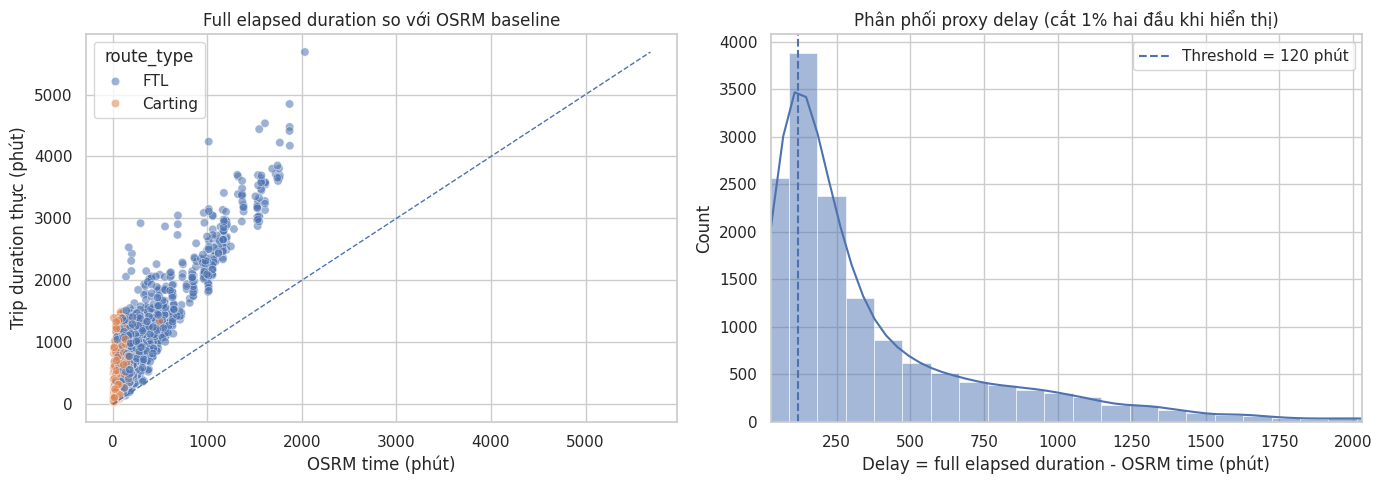

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = trip_df.sample(min(5000, len(trip_df)), random_state=RANDOM_STATE)
sns.scatterplot(
    data=sample, x='osrm_time', y='trip_duration_minutes',
    hue='route_type', alpha=.55, ax=axes[0]
)
max_time = max(sample['osrm_time'].max(), sample['trip_duration_minutes'].max())
axes[0].plot([0, max_time], [0, max_time], linestyle='--', linewidth=1)
axes[0].set_title('Full elapsed duration so với OSRM baseline')
axes[0].set_xlabel('OSRM time (phút)')
axes[0].set_ylabel('Trip duration thực (phút)')

sns.histplot(trip_df['delay_minutes'], bins=80, kde=True, ax=axes[1], color='C0')
axes[1].axvline(
    DELAY_THRESHOLD_MINUTES, linestyle='--',
    label=f'Threshold = {DELAY_THRESHOLD_MINUTES} phút'
)
axes[1].set_xlim(trip_df['delay_minutes'].quantile(.01), trip_df['delay_minutes'].quantile(.99))
axes[1].set_title('Phân phối proxy delay (cắt 1% hai đầu khi hiển thị)')
axes[1].set_xlabel('Delay = full elapsed duration - OSRM time (phút)')
axes[1].legend()

plt.tight_layout()
plt.show()

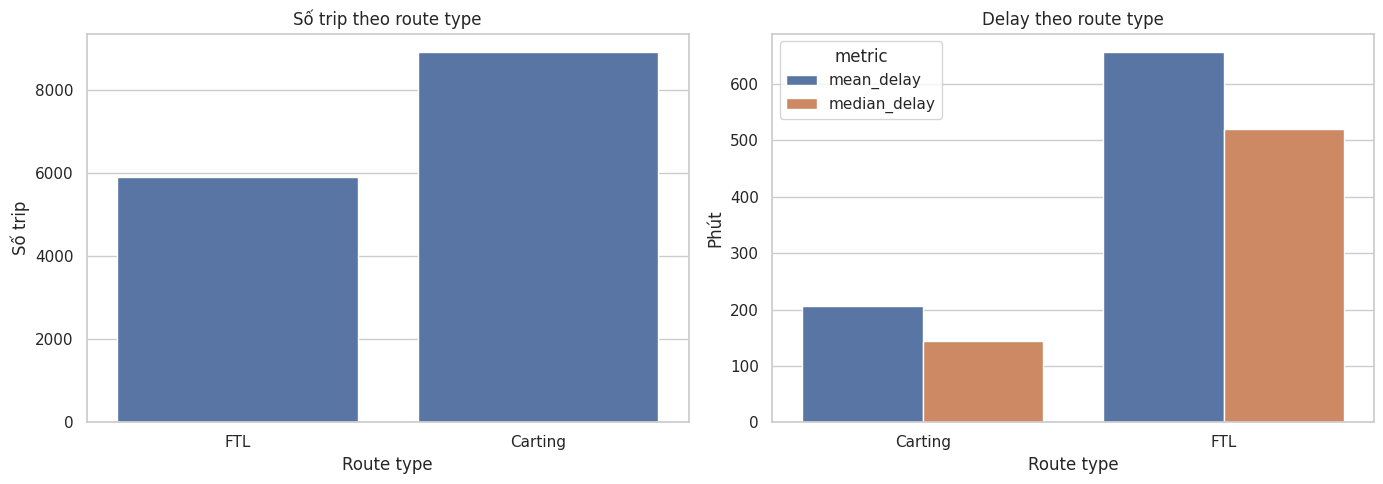

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=trip_df, x='route_type', ax=axes[0], color='C0')
axes[0].set_title('Số trip theo route type')
axes[0].set_xlabel('Route type')
axes[0].set_ylabel('Số trip')

route_delay = (
    trip_df.groupby('route_type', as_index=False)
           .agg(mean_delay=('delay_minutes', 'mean'), median_delay=('delay_minutes', 'median'))
)
route_delay_melt = route_delay.melt('route_type', var_name='metric', value_name='delay_minutes')
sns.barplot(data=route_delay_melt, x='route_type', y='delay_minutes', hue='metric', ax=axes[1], palette='deep')
axes[1].set_title('Delay theo route type')
axes[1].set_xlabel('Route type')
axes[1].set_ylabel('Phút')

plt.tight_layout()
plt.show()

,state_corridor,trips,mean_delay,median_delay,mean_trip_duration
0,Punjab → Karnataka,20,"2,033.478","2,034.250","3,782.328"
1,Haryana → Telangana,26,"1,808.370","1,928.518","3,116.831"
2,Karnataka → Haryana,38,"1,673.450","1,658.819","3,226.345"
3,Haryana → Karnataka,47,"1,572.965","1,517.846","3,116.093"
4,Haryana → West Bengal,32,"1,457.948","1,356.263","2,473.885"
5,West Bengal → Haryana,26,"1,394.229","1,398.169","2,481.421"
6,Delhi → Maharashtra,37,"1,231.963","1,186.976","2,257.314"
7,Gujarat → Karnataka,20,"1,227.181","1,211.308","2,201.731"
8,Haryana → Maharashtra,22,"1,203.878","1,160.248","2,172.741"
9,Maharashtra → Haryana,44,"1,114.545","1,129.711","2,101.681"


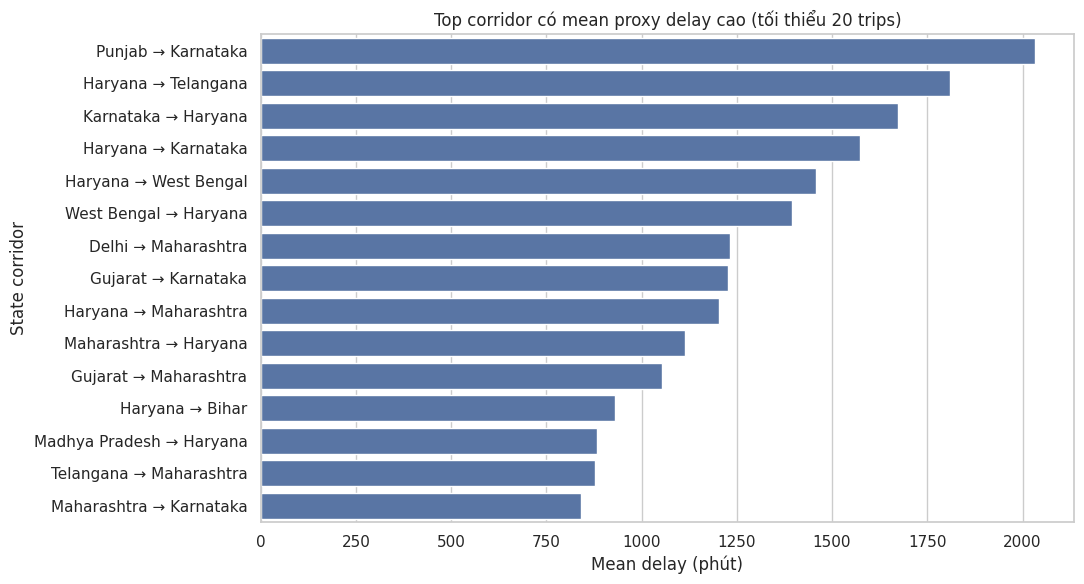

In [14]:
trip_df['state_corridor'] = trip_df['source_state'] + ' → ' + trip_df['destination_state']

corridor_summary = (
    trip_df.groupby('state_corridor')
           .agg(
               trips=('trip_uuid', 'size'),
               mean_delay=('delay_minutes', 'mean'),
               median_delay=('delay_minutes', 'median'),
               mean_trip_duration=('trip_duration_minutes', 'mean'),
           )
           .query('trips >= 20')
           .sort_values('mean_delay', ascending=False)
           .head(15)
           .reset_index()
)

display(corridor_summary)

plt.figure(figsize=(11, 6))
sns.barplot(data=corridor_summary, x='mean_delay', y='state_corridor', color='C0')
plt.title('Top corridor có mean proxy delay cao (tối thiểu 20 trips)')
plt.xlabel('Mean delay (phút)')
plt.ylabel('State corridor')
plt.tight_layout()
plt.show()

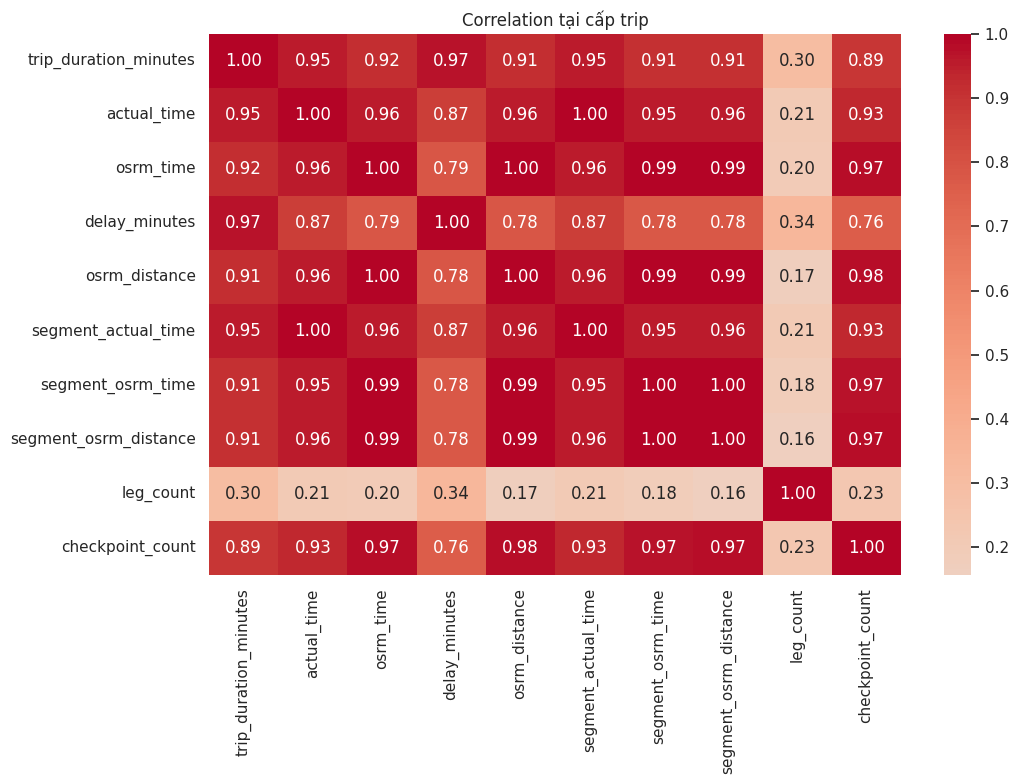

In [15]:
corr_cols = [
    'trip_duration_minutes', 'actual_time', 'osrm_time', 'delay_minutes',
    'osrm_distance', 'segment_actual_time', 'segment_osrm_time',
    'segment_osrm_distance', 'leg_count', 'checkpoint_count'
]
plt.figure(figsize=(11, 8))
sns.heatmap(trip_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation tại cấp trip')
plt.tight_layout()
plt.show()

## 7. Feature Engineering


### Features for the Start-of-Trip Model

Only information guaranteed to be available before or at departure is used:

- the route plan's `osrm_time`, `osrm_distance`;
- origin, destination, and route type;
- departure hour/day;
- ratios computed only from the OSRM plan.

`segment_osrm_*`, `leg_count`, and `checkpoint_count` are not used because they are aggregated from all actual rows and may not be fully known at departure. No actual/cutoff/end-time variable is used.


In [16]:
trip_df['start_hour'] = trip_df['trip_start_time'].dt.hour
trip_df['start_dayofweek'] = trip_df['trip_start_time'].dt.dayofweek
trip_df['start_month'] = trip_df['trip_start_time'].dt.month
trip_df['is_weekend'] = trip_df['start_dayofweek'].isin([5, 6]).astype(int)
trip_df['state_corridor'] = trip_df['source_state'] + ' → ' + trip_df['destination_state']

trip_df['planned_speed_kmph'] = (
    trip_df['osrm_distance'] / (trip_df['osrm_time'] / 60).replace(0, np.nan)
)
trip_df['planned_minutes_per_km'] = (
    trip_df['osrm_time'] / trip_df['osrm_distance'].replace(0, np.nan)
)
trip_df = trip_df.replace([np.inf, -np.inf], np.nan)

START_NUMERIC_FEATURES = [
    'osrm_time', 'osrm_distance',
    'start_hour', 'start_dayofweek', 'start_month', 'is_weekend',
    'planned_speed_kmph', 'planned_minutes_per_km',
]

START_CATEGORICAL_FEATURES = [
    'route_type', 'source_state', 'destination_state', 'state_corridor'
]

START_FEATURES = START_NUMERIC_FEATURES + START_CATEGORICAL_FEATURES

print(f'Number of start-of-trip model features: {len(START_FEATURES)}')
display(trip_df[START_FEATURES + ['trip_duration_minutes', 'delay_minutes']].head())

Number of start-of-trip model features: 12


,osrm_time,osrm_distance,start_hour,start_dayofweek,start_month,is_weekend,planned_speed_kmph,planned_minutes_per_km,route_type,source_state,destination_state,state_corridor,trip_duration_minutes,delay_minutes
0,743.000,991.352,0,2,9,0,80.055,0.749,FTL,Madhya Pradesh,Haryana,Madhya Pradesh → Haryana,"2,260.110","1,517.110"
1,68.000,85.111,0,2,9,0,75.098,0.799,Carting,Karnataka,Karnataka,Karnataka → Karnataka,181.612,113.612
2,"1,741.000","2,372.085",0,2,9,0,81.749,0.734,FTL,Karnataka,Punjab,Karnataka → Punjab,"3,934.363","2,193.363"
3,15.000,19.680,0,2,9,0,78.720,0.762,Carting,Maharashtra,Maharashtra,Maharashtra → Maharashtra,100.495,85.495
4,117.000,146.792,0,2,9,0,75.278,0.797,FTL,Karnataka,Karnataka,Karnataka → Karnataka,718.349,601.349


## 8. Data Splitting and Leakage Prevention


The dataset has a built-in external time-based split:

- `training`: the earlier period;
- `test`: the later period.

The final test set is kept intact and used **only once**, after the model has been selected. Within `training`, the notebook creates an additional chronological 80/20 fit/validation split to compare models and choose the classification threshold.


In [17]:
train_df = trip_df.query("data == 'training'").copy().sort_values('trip_creation_time')
test_df = trip_df.query("data == 'test'").copy().sort_values('trip_creation_time')

trip_overlap = set(train_df['trip_uuid']).intersection(test_df['trip_uuid'])
assert len(trip_overlap) == 0, 'Có trip_uuid trùng giữa external train và test.'

validation_start = int(len(train_df) * 0.80)
fit_df = train_df.iloc[:validation_start].copy()
validation_df = train_df.iloc[validation_start:].copy()

fit_val_overlap = set(fit_df['trip_uuid']).intersection(validation_df['trip_uuid'])
assert len(fit_val_overlap) == 0, 'Có trip_uuid trùng giữa fit và validation.'
assert fit_df['trip_creation_time'].max() <= validation_df['trip_creation_time'].min()

split_summary = pd.DataFrame({
    'split': ['fit', 'validation', 'final test'],
    'n_trips': [len(fit_df), len(validation_df), len(test_df)],
    'pct_all_trips': [len(fit_df)/len(trip_df), len(validation_df)/len(trip_df), len(test_df)/len(trip_df)],
    'start_date': [
        fit_df['trip_creation_time'].min(), validation_df['trip_creation_time'].min(),
        test_df['trip_creation_time'].min()
    ],
    'end_date': [
        fit_df['trip_creation_time'].max(), validation_df['trip_creation_time'].max(),
        test_df['trip_creation_time'].max()
    ],
    'mean_duration': [
        fit_df['trip_duration_minutes'].mean(), validation_df['trip_duration_minutes'].mean(),
        test_df['trip_duration_minutes'].mean()
    ],
    'mean_delay': [fit_df['delay_minutes'].mean(), validation_df['delay_minutes'].mean(), test_df['delay_minutes'].mean()],
})

display(split_summary)
print(f'External train trips: {len(train_df):,} ({len(train_df)/len(trip_df):.2%})')
print(f'Final test trips: {len(test_df):,} ({len(test_df)/len(trip_df):.2%})')
print(f'Trip overlap external train/test: {len(trip_overlap)}')

,split,n_trips,pct_all_trips,start_date,end_date,mean_duration,mean_delay
0,fit,8523,0.575,2018-09-12 00:00:16.535741,2018-09-23 22:15:46.635975,545.265,382.142
1,validation,2131,0.144,2018-09-23 22:16:47.064680,2018-09-26 23:54:27.945614,570.765,399.243
2,final test,4163,0.281,2018-09-27 00:02:18.970980,2018-10-03 23:59:42.701692,540.085,384.998


External train trips: 10,654 (71.90%)
Final test trips: 4,163 (28.10%)
Trip overlap external train/test: 0


### Leakage Guard

The following columns **must not be fed into the start-of-trip ETA model**:

- `actual_time`, `segment_actual_time`, `actual_distance_to_destination`;
- `factor`, `segment_factor`, because they are derived directly from actual/planned time;
- `od_end_time`, `trip_end_time`, `start_scan_to_end_scan`;
- `cutoff_timestamp`, `cutoff_factor`, `cutoff_rate`, if predicting before the trip starts;
- `delay_minutes`, `actual_eta`, because they are the target or derived from the target.


In [18]:
LEAKAGE_COLUMNS = {
    'actual_time', 'segment_actual_time', 'actual_distance_to_destination',
    'factor', 'segment_factor', 'od_end_time', 'trip_end_time',
    'start_scan_to_end_scan', 'cutoff_timestamp', 'cutoff_factor',
    'cutoff_rate', 'delay_minutes', 'delay_ratio', 'actual_eta',
    'trip_duration_minutes', 'actual_time_gap_vs_elapsed',
    'segment_osrm_time', 'segment_osrm_distance', 'leg_count', 'checkpoint_count'
}

leaked = LEAKAGE_COLUMNS.intersection(START_FEATURES)
assert not leaked, f'Feature set chứa biến leakage/future information: {leaked}'
print('Start-of-trip leakage check passed.')

Start-of-trip leakage check passed.


In [19]:
def make_start_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('numeric', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), START_NUMERIC_FEATURES),
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(
                    handle_unknown='ignore',
                    min_frequency=10,
                    sparse_output=True,
                )),
            ]), START_CATEGORICAL_FEATURES),
        ],
        remainder='drop',
    )


ETA_MODEL_NAMES = [
    'Ridge',
    'Decision Tree',
    'Random Forest',
    'Extra Trees',
    'AdaBoost',
    'XGBoost',
]


def make_eta_model(model_name):
    """Khởi tạo model ETA với cấu hình cố định trước khi xem final test."""
    if model_name == 'Ridge':
        return Ridge(alpha=10.0, solver='lsqr')

    if model_name == 'Decision Tree':
        return DecisionTreeRegressor(
            max_depth=18,
            min_samples_split=8,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
        )

    if model_name == 'Random Forest':
        return RandomForestRegressor(
            n_estimators=70 if FAST_MODE else 220,
            max_depth=18,
            min_samples_leaf=2,
            max_features='sqrt',
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        )

    if model_name == 'Extra Trees':
        return ExtraTreesRegressor(
            n_estimators=70 if FAST_MODE else 220,
            max_depth=None,
            min_samples_leaf=2,
            max_features=1.0,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        )

    if model_name == 'AdaBoost':
        weak_tree = DecisionTreeRegressor(
            max_depth=6,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
        )
        return AdaBoostRegressor(
            estimator=weak_tree,
            n_estimators=60 if FAST_MODE else 180,
            learning_rate=0.04,
            loss='square',
            random_state=RANDOM_STATE,
        )

    if model_name == 'XGBoost':
        return XGBRegressor(
            n_estimators=120 if FAST_MODE else 300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective='reg:squarederror',
            eval_metric='mae',
            tree_method='hist',
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        )

    raise ValueError(f'Unknown model: {model_name}')


## 9. ETA Regression Model


The model predicts the **full elapsed duration**:

\[
Duration = trip\_end\_time - trip\_start\_time
\]

\[
\widehat{ETA} = trip\_start\_time + \widehat{Duration}
\]

Models are compared fairly on the same features and the same chronological split:

- `Ridge`: a linear baseline;
- `Decision Tree`: a single tree, easy to interpret but prone to overfitting;
- `Random Forest`: bagging of many trees to reduce variance;
- `Extra Trees`: adds extra randomness when choosing split points, usually fast and stable;
- `AdaBoost`: progressively focuses on samples that were predicted incorrectly;
- `XGBoost`: gradient boosting with regularization.

Procedure:

1. Fit every model on the chronological `fit` split.
2. Select the model with the lowest MAE on `validation`.
3. Refit the selected model on the full external `training` set.
4. Evaluate exactly once on `final test`.
5. Compare the selected model against the OSRM baseline.

> `FAST_MODE=True` only reduces the number of trees for quick trials; the model-selection logic is unchanged.


In [20]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MedianAE': median_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }


validation_preprocessor = make_start_preprocessor()
X_fit_t = validation_preprocessor.fit_transform(fit_df[START_FEATURES])
X_validation_t = validation_preprocessor.transform(validation_df[START_FEATURES])

y_fit_eta = fit_df['trip_duration_minutes']
y_validation_eta = validation_df['trip_duration_minutes']

eta_validation_predictions = {
    'OSRM baseline': validation_df['osrm_time'].to_numpy()
}
eta_validation_models = {}
eta_validation_results = [{
    'Model': 'OSRM baseline',
    'Family': 'Routing baseline',
    'Fit seconds': 0.0,
    'Predict seconds': 0.0,
    **regression_metrics(y_validation_eta, eta_validation_predictions['OSRM baseline'])
}]

for model_name in ETA_MODEL_NAMES:
    model = make_eta_model(model_name)

    fit_start = time.perf_counter()
    model.fit(X_fit_t, y_fit_eta)
    fit_seconds = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    pred = model.predict(X_validation_t)
    predict_seconds = time.perf_counter() - predict_start

    eta_validation_models[model_name] = model
    eta_validation_predictions[model_name] = pred
    eta_validation_results.append({
        'Model': model_name,
        'Family': 'Linear' if model_name == 'Ridge' else 'Tree-based',
        'Fit seconds': fit_seconds,
        'Predict seconds': predict_seconds,
        **regression_metrics(y_validation_eta, pred),
    })

eta_validation_results_df = (
    pd.DataFrame(eta_validation_results)
      .sort_values(['MAE', 'RMSE'])
      .reset_index(drop=True)
)
display(eta_validation_results_df.style.set_caption('Model selection — chronological validation only'))

best_eta_model_name = (
    eta_validation_results_df
      .query("Model != 'OSRM baseline'")
      .sort_values(['MAE', 'RMSE'])
      .iloc[0]['Model']
)
print(f'Selected ETA model from validation: {best_eta_model_name}')

start_preprocessor = make_start_preprocessor()
X_train_t = start_preprocessor.fit_transform(train_df[START_FEATURES])
X_test_t = start_preprocessor.transform(test_df[START_FEATURES])
feature_names = start_preprocessor.get_feature_names_out()

y_train_eta = train_df['trip_duration_minutes']
y_test_eta = test_df['trip_duration_minutes']

final_eta_model = make_eta_model(best_eta_model_name)
final_fit_start = time.perf_counter()
final_eta_model.fit(X_train_t, y_train_eta)
final_eta_fit_seconds = time.perf_counter() - final_fit_start

final_predict_start = time.perf_counter()
best_eta_pred = final_eta_model.predict(X_test_t)
final_eta_predict_seconds = time.perf_counter() - final_predict_start

eta_test_results_df = pd.DataFrame([
    {
        'Model': 'OSRM baseline',
        'Fit seconds': 0.0,
        'Predict seconds': 0.0,
        **regression_metrics(y_test_eta, test_df['osrm_time'].to_numpy()),
    },
    {
        'Model': best_eta_model_name,
        'Fit seconds': final_eta_fit_seconds,
        'Predict seconds': final_eta_predict_seconds,
        **regression_metrics(y_test_eta, best_eta_pred),
    },
]).sort_values('MAE').reset_index(drop=True)

display(eta_test_results_df.style.set_caption('Final test — selected model evaluated once'))
print(f'Transformed full train shape: {X_train_t.shape}')
print(f'Transformed final test shape: {X_test_t.shape}')


,Model,Family,Fit seconds,Predict seconds,MAE,MedianAE,RMSE,R2
0,Extra Trees,Tree-based,32.082466,0.116375,101.526885,52.951363,182.862218,0.926364
1,XGBoost,Tree-based,0.389415,0.011788,123.460310,72.592320,201.781237,0.910339
2,Decision Tree,Tree-based,0.250075,0.001006,126.414695,62.977838,222.501775,0.890979
3,Random Forest,Tree-based,3.703335,0.096597,128.026948,79.601954,205.439594,0.907058
4,Ridge,Linear,0.025907,0.000310,151.456495,101.207713,228.638294,0.884883
5,AdaBoost,Tree-based,9.742344,0.091094,160.809321,108.387554,235.477899,0.877892
6,OSRM baseline,Routing baseline,0.000000,0.000000,399.251664,228.954665,584.855719,0.246747


Selected ETA model from validation: Extra Trees


,Model,Fit seconds,Predict seconds,MAE,MedianAE,RMSE,R2
0,Extra Trees,43.455970,0.167398,104.905686,53.071210,223.718955,0.897965
1,OSRM baseline,0.000000,0.000000,384.997853,208.914406,599.942470,0.266225


Transformed full train shape: (10654, 157)
Transformed final test shape: (4163, 157)


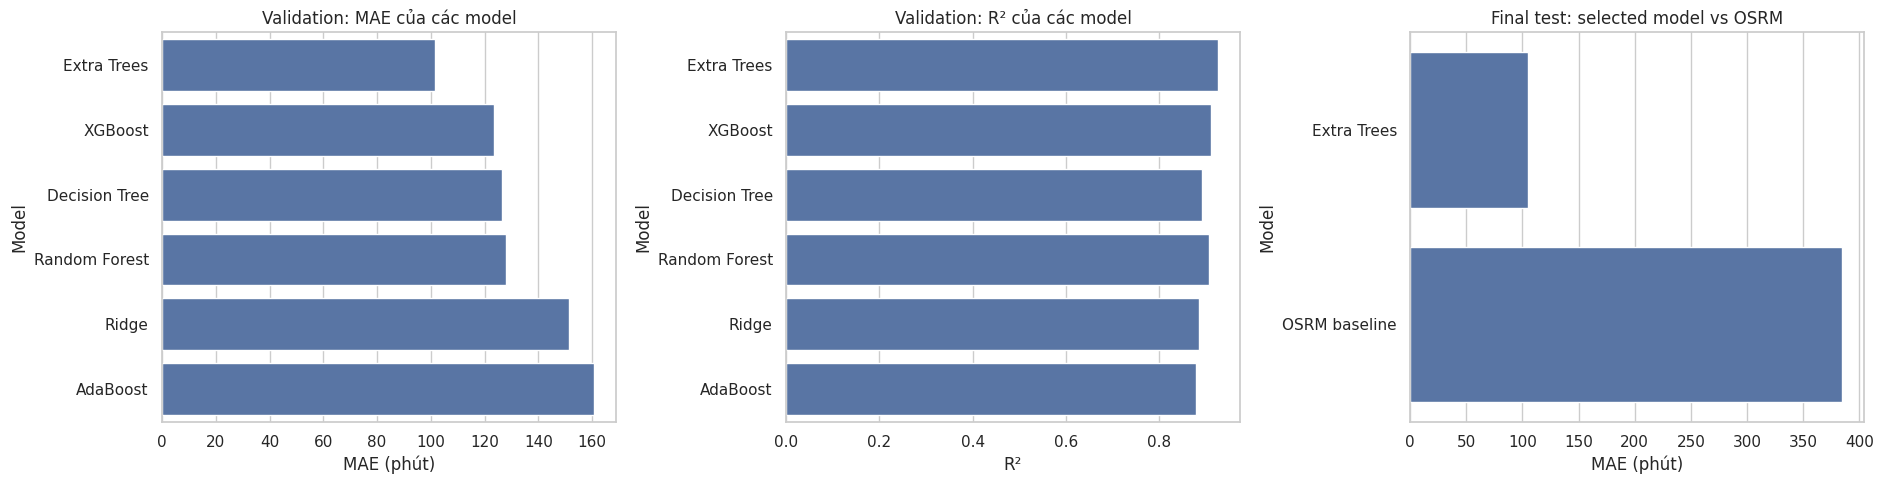

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

validation_plot_df = eta_validation_results_df.query("Model != 'OSRM baseline'")

sns.barplot(data=validation_plot_df, x='MAE', y='Model', ax=axes[0], color='C0')
axes[0].set_title('Validation: MAE của các model')
axes[0].set_xlabel('MAE (phút)')

sns.barplot(data=validation_plot_df, x='R2', y='Model', ax=axes[1], color='C0')
axes[1].set_title('Validation: R² của các model')
axes[1].set_xlabel('R²')

sns.barplot(data=eta_test_results_df, x='MAE', y='Model', ax=axes[2], color='C0')
axes[2].set_title('Final test: selected model vs OSRM')
axes[2].set_xlabel('MAE (phút)')

plt.tight_layout()
plt.show()


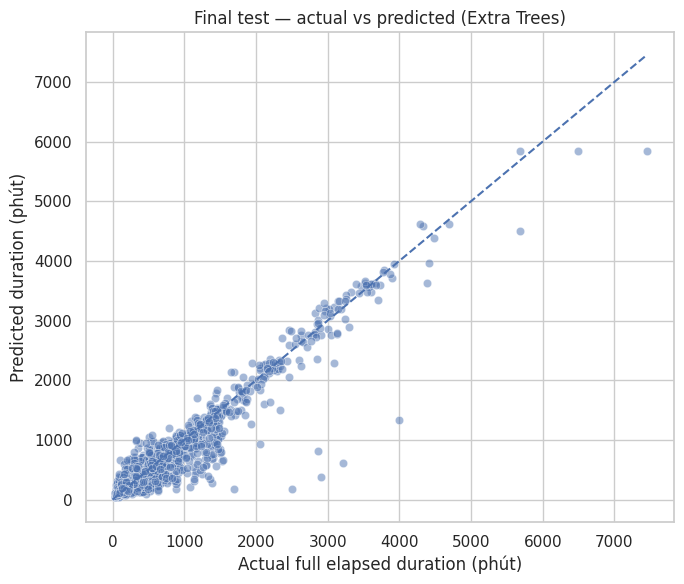

In [22]:
plot_df = pd.DataFrame({
    'Actual': y_test_eta.to_numpy(),
    'Predicted': best_eta_pred,
}).sample(min(2500, len(test_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=plot_df, x='Actual', y='Predicted', alpha=.5, color='C0')
max_value = max(plot_df['Actual'].max(), plot_df['Predicted'].max())
plt.plot([0, max_value], [0, max_value], linestyle='--')
plt.title(f'Final test — actual vs predicted ({best_eta_model_name})')
plt.xlabel('Actual full elapsed duration (phút)')
plt.ylabel('Predicted duration (phút)')
plt.tight_layout()
plt.show()

## 10. Delay Magnitude Model


Delay magnitude is derived directly from the same ETA/duration prediction:

\[
\widehat{Delay} = \widehat{Duration} - OSRMTime
\]

This keeps the predicted ETA and predicted delay always consistent. It is a **proxy delay relative to the OSRM routing baseline**, not an official SLA delay.


In [23]:
y_test_delay = test_df['delay_minutes']

delay_pred = best_eta_pred - test_df['osrm_time'].to_numpy()

delay_results_df = pd.DataFrame([
    {
        'Model': 'Zero-delay / OSRM baseline',
        **regression_metrics(y_test_delay, np.zeros(len(y_test_delay)))
    },
    {
        'Model': f'Derived from {best_eta_model_name}',
        **regression_metrics(y_test_delay, delay_pred)
    },
]).sort_values('MAE').reset_index(drop=True)

display(delay_results_df)

,Model,MAE,MedianAE,RMSE,R2
0,Derived from Extra Trees,104.906,53.071,223.719,0.764
1,Zero-delay / OSRM baseline,384.998,208.914,599.942,-0.700


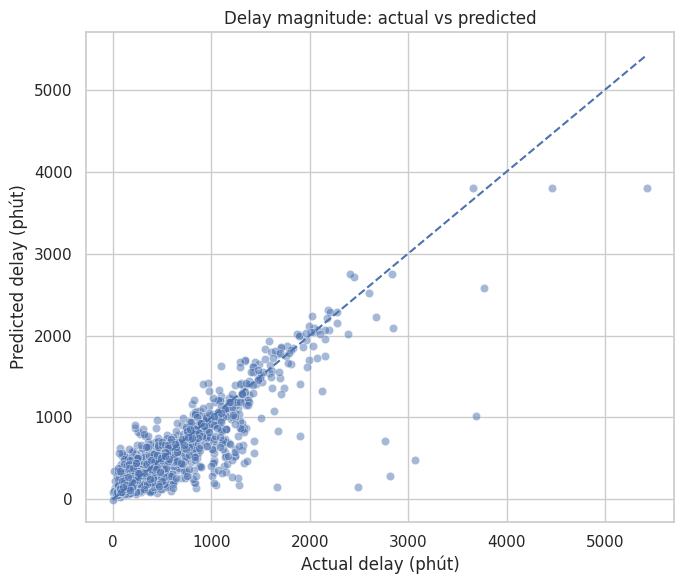

In [24]:
delay_plot = pd.DataFrame({
    'Actual delay': y_test_delay.to_numpy(),
    'Predicted delay': delay_pred,
}).sample(min(2500, len(test_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=delay_plot, x='Actual delay', y='Predicted delay', alpha=.5, color='C0')
low = min(delay_plot.min())
high = max(delay_plot.max())
plt.plot([low, high], [low, high], linestyle='--')
plt.title('Delay magnitude: actual vs predicted')
plt.xlabel('Actual delay (phút)')
plt.ylabel('Predicted delay (phút)')
plt.tight_layout()
plt.show()

## 11. Severe Delay Probability Model


Severe delay is defined using an adjustable SLA proxy:

\[
SevereDelay = 1 \quad if \quad Delay > 120\;minutes
\]

The notebook compares five tree-based classifiers on the same chronological validation set:

- Decision Tree;
- Random Forest;
- Extra Trees;
- AdaBoost;
- XGBoost.

For **each model**, a separate probability threshold is chosen to maximize validation F1. The notebook then selects the classifier with the highest validation F1, refits that classifier on the full external training set, and evaluates the final test set once. This avoids defaulting to a 0.5 threshold and avoids selecting the model using the final test set.


In [25]:
CLASSIFIER_MODEL_NAMES = [
    'Decision Tree',
    'Random Forest',
    'Extra Trees',
    'AdaBoost',
    'XGBoost',
]


def make_classifier(model_name, scale_pos_weight=1.0):
    """Khởi tạo classifier; imbalance được xử lý phù hợp theo từng họ model."""
    if model_name == 'Decision Tree':
        return DecisionTreeClassifier(
            max_depth=16,
            min_samples_split=8,
            min_samples_leaf=3,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )

    if model_name == 'Random Forest':
        return RandomForestClassifier(
            n_estimators=70 if FAST_MODE else 220,
            max_depth=18,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        )

    if model_name == 'Extra Trees':
        return ExtraTreesClassifier(
            n_estimators=70 if FAST_MODE else 220,
            max_depth=None,
            min_samples_leaf=2,
            max_features=1.0,
            class_weight='balanced',
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        )

    if model_name == 'AdaBoost':
        weak_tree = DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
        )
        return AdaBoostClassifier(
            estimator=weak_tree,
            n_estimators=60 if FAST_MODE else 180,
            learning_rate=0.04,
            random_state=RANDOM_STATE,
        )

    if model_name == 'XGBoost':
        return XGBClassifier(
            n_estimators=120 if FAST_MODE else 250,
            max_depth=5,
            learning_rate=0.06,
            subsample=0.85,
            colsample_bytree=0.85,
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            scale_pos_weight=scale_pos_weight,
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        )

    raise ValueError(f'Unknown classifier: {model_name}')


def best_f1_threshold(y_true, probability):
    rows = []
    for threshold in np.linspace(0.10, 0.90, 81):
        pred = (probability >= threshold).astype(int)
        rows.append({
            'threshold': threshold,
            'F1': f1_score(y_true, pred, zero_division=0),
            'Precision': precision_score(y_true, pred, zero_division=0),
            'Recall': recall_score(y_true, pred, zero_division=0),
        })

    table = pd.DataFrame(rows)
    best_row = table.sort_values(
        ['F1', 'Recall', 'Precision'], ascending=False
    ).iloc[0]
    return float(best_row['threshold']), table


y_fit_cls = (fit_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int)
y_validation_cls = (validation_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int)

fit_neg = (y_fit_cls == 0).sum()
fit_pos = (y_fit_cls == 1).sum()
fit_scale_pos_weight = fit_neg / max(fit_pos, 1)
fit_balanced_sample_weight = compute_sample_weight(class_weight='balanced', y=y_fit_cls)

classifier_validation_results = []
classifier_validation_models = {}
classification_threshold_results_by_model = {}

for model_name in CLASSIFIER_MODEL_NAMES:
    model = make_classifier(model_name, fit_scale_pos_weight)

    fit_start = time.perf_counter()
    if model_name == 'AdaBoost':
        model.fit(X_fit_t, y_fit_cls, sample_weight=fit_balanced_sample_weight)
    else:
        model.fit(X_fit_t, y_fit_cls)
    fit_seconds = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    probability = model.predict_proba(X_validation_t)[:, 1]
    predict_seconds = time.perf_counter() - predict_start

    selected_threshold, threshold_table = best_f1_threshold(
        y_validation_cls, probability
    )
    pred = (probability >= selected_threshold).astype(int)

    classifier_validation_models[model_name] = model
    classification_threshold_results_by_model[model_name] = threshold_table
    classifier_validation_results.append({
        'Model': model_name,
        'Probability threshold': selected_threshold,
        'Accuracy': accuracy_score(y_validation_cls, pred),
        'Precision': precision_score(y_validation_cls, pred, zero_division=0),
        'Recall': recall_score(y_validation_cls, pred, zero_division=0),
        'F1': f1_score(y_validation_cls, pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_validation_cls, probability),
        'Fit seconds': fit_seconds,
        'Predict seconds': predict_seconds,
    })

classifier_validation_results_df = (
    pd.DataFrame(classifier_validation_results)
      .sort_values(['F1', 'ROC_AUC', 'Recall'], ascending=False)
      .reset_index(drop=True)
)
display(classifier_validation_results_df.style.set_caption(
    'Classifier selection — chronological validation only'
))

best_classifier_name = classifier_validation_results_df.iloc[0]['Model']
best_classification_threshold = float(
    classifier_validation_results_df.iloc[0]['Probability threshold']
)
threshold_results_df = classification_threshold_results_by_model[best_classifier_name]

print(f'Selected severe-delay classifier: {best_classifier_name}')
print(f'Selected probability threshold from validation: {best_classification_threshold:.2f}')
display(threshold_results_df.sort_values('F1', ascending=False).head(10))

y_train_cls = (train_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int)
y_test_cls = (test_df['delay_minutes'] > DELAY_THRESHOLD_MINUTES).astype(int)

train_neg = (y_train_cls == 0).sum()
train_pos = (y_train_cls == 1).sum()
train_scale_pos_weight = train_neg / max(train_pos, 1)
train_balanced_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train_cls)

classifier = make_classifier(best_classifier_name, train_scale_pos_weight)
classifier_fit_start = time.perf_counter()
if best_classifier_name == 'AdaBoost':
    classifier.fit(X_train_t, y_train_cls, sample_weight=train_balanced_sample_weight)
else:
    classifier.fit(X_train_t, y_train_cls)
classifier_fit_seconds = time.perf_counter() - classifier_fit_start

classifier_predict_start = time.perf_counter()
severe_delay_probability = classifier.predict_proba(X_test_t)[:, 1]
classifier_predict_seconds = time.perf_counter() - classifier_predict_start

severe_delay_pred = (
    severe_delay_probability >= best_classification_threshold
).astype(int)

classification_metrics = pd.DataFrame([{
    'Model': best_classifier_name,
    'Probability threshold': best_classification_threshold,
    'Accuracy': accuracy_score(y_test_cls, severe_delay_pred),
    'Precision': precision_score(y_test_cls, severe_delay_pred, zero_division=0),
    'Recall': recall_score(y_test_cls, severe_delay_pred, zero_division=0),
    'F1': f1_score(y_test_cls, severe_delay_pred, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test_cls, severe_delay_probability),
    'Fit seconds': classifier_fit_seconds,
    'Predict seconds': classifier_predict_seconds,
}])

display(classification_metrics.style.set_caption('Final test — selected classifier evaluated once'))
print(f'Train positive rate: {y_train_cls.mean():.2%}')
print(f'Test positive rate: {y_test_cls.mean():.2%}')
print(classification_report(y_test_cls, severe_delay_pred, digits=3, zero_division=0))


,Model,Probability threshold,Accuracy,Precision,Recall,F1,ROC_AUC,Fit seconds,Predict seconds
0,Extra Trees,0.350000,0.861098,0.890378,0.926489,0.908075,0.921453,17.422853,0.096138
1,Random Forest,0.330000,0.848897,0.873365,0.930925,0.901227,0.915911,3.277796,0.085223
2,XGBoost,0.220000,0.842797,0.863238,0.935995,0.898145,0.914998,0.258107,0.008953
3,Decision Tree,0.180000,0.831065,0.872249,0.904309,0.887990,0.844694,0.183298,0.000749
4,AdaBoost,0.320000,0.824026,0.845095,0.933460,0.887082,0.882253,6.671842,0.089607


Selected severe-delay classifier: Extra Trees
Selected probability threshold from validation: 0.35


,threshold,F1,Precision,Recall
25,0.350,0.908,0.890,0.926
24,0.340,0.907,0.887,0.928
22,0.320,0.907,0.883,0.932
26,0.360,0.907,0.892,0.922
18,0.280,0.906,0.874,0.940
27,0.370,0.906,0.894,0.919
23,0.330,0.906,0.884,0.930
19,0.290,0.906,0.876,0.938
28,0.380,0.906,0.895,0.916
21,0.310,0.905,0.878,0.934


,Model,Probability threshold,Accuracy,Precision,Recall,F1,ROC_AUC,Fit seconds,Predict seconds
0,Extra Trees,0.350000,0.853471,0.880616,0.920188,0.899967,0.911799,23.530784,0.127148


Train positive rate: 72.66%
Test positive rate: 71.63%
              precision    recall  f1-score   support

           0      0.773     0.685     0.726      1181
           1      0.881     0.920     0.900      2982

    accuracy                          0.853      4163
   macro avg      0.827     0.803     0.813      4163
weighted avg      0.850     0.853     0.851      4163



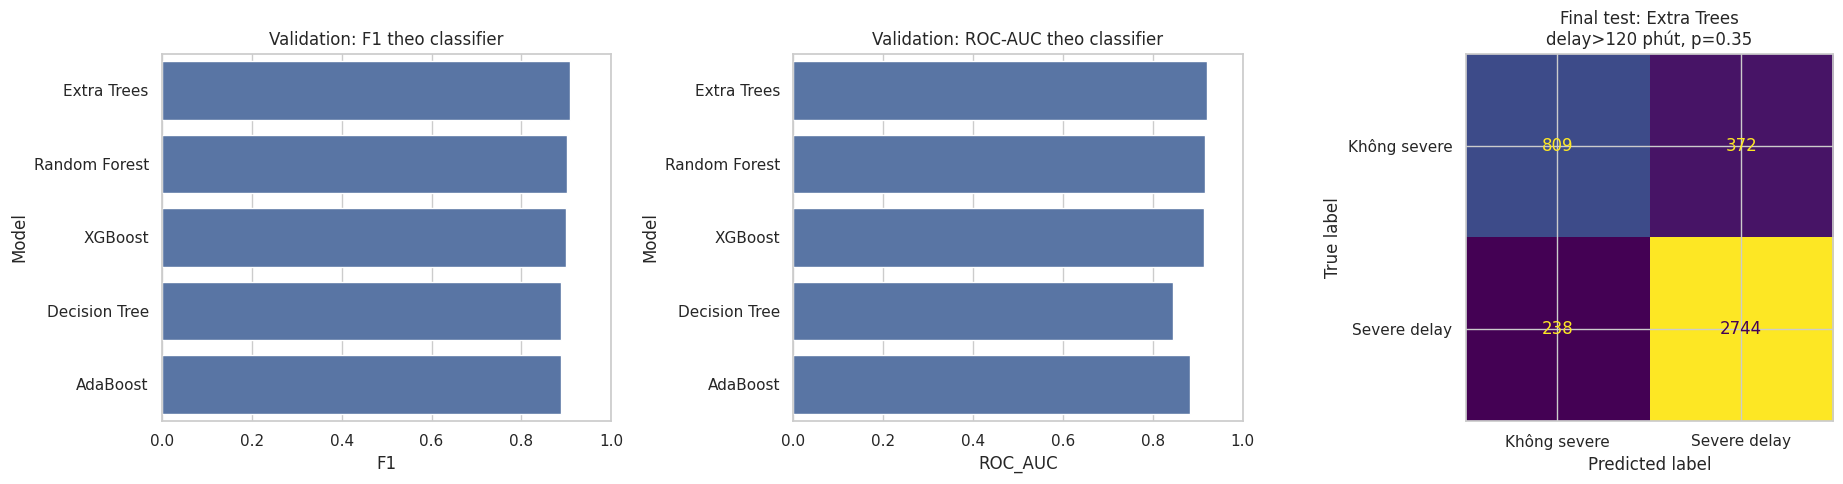

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.barplot(
    data=classifier_validation_results_df,
    x='F1', y='Model', ax=axes[0], color='C0'
)
axes[0].set_title('Validation: F1 theo classifier')
axes[0].set_xlim(0, 1)

sns.barplot(
    data=classifier_validation_results_df,
    x='ROC_AUC', y='Model', ax=axes[1], color='C0'
)
axes[1].set_title('Validation: ROC-AUC theo classifier')
axes[1].set_xlim(0, 1)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_cls, severe_delay_pred),
    display_labels=['Không severe', 'Severe delay']
).plot(ax=axes[2], values_format='d', colorbar=False)
axes[2].set_title(
    f'Final test: {best_classifier_name}\n'
    f'delay>{DELAY_THRESHOLD_MINUTES} phút, p={best_classification_threshold:.2f}'
)

plt.tight_layout()
plt.show()


## 12. Delay Propagation Model


The start-of-trip model uses only planned information. To represent delay propagation, the notebook creates a snapshot after each observed checkpoint.

At checkpoint \(k\):

\[
StageDelay_k = SegmentActualTime_k - SegmentOSRMTime_k
\]

\[
CumulativeDelay_k = \sum_{i=1}^{k} StageDelay_i
\]

Checkpoints are sorted by `cutoff_timestamp`. `total_stages` is excluded because it is future information. Progress is normalized by the route's total planned segment time, assuming the segment plan is available in advance. The final score is computed at 25%, 50%, 75%, and 100% progress, with each trip contributing a single observation.


In [27]:
stage_df = df.query('segment_actual_time >= 0 and segment_osrm_time > 0').copy()
stage_df = stage_df.sort_values(
    ['trip_uuid', 'od_start_time', 'cutoff_timestamp', '_row_order'],
    na_position='last',
).reset_index(drop=True)

trip_targets = trip_df[[
    'trip_uuid', 'trip_duration_minutes', 'osrm_time', 'osrm_distance', 'delay_minutes'
]].rename(columns={
    'trip_duration_minutes': 'final_trip_duration',
    'osrm_time': 'trip_osrm_time',
    'osrm_distance': 'trip_osrm_distance',
    'delay_minutes': 'final_delay_minutes',
})

stage_df = stage_df.merge(trip_targets, on='trip_uuid', how='inner')
stage_group = stage_df.groupby('trip_uuid', sort=False)

stage_df['stage_index'] = stage_group.cumcount() + 1
stage_df['total_segment_osrm_time'] = stage_group['segment_osrm_time'].transform('sum')
stage_df['cum_actual_time'] = stage_group['segment_actual_time'].cumsum()
stage_df['cum_osrm_time'] = stage_group['segment_osrm_time'].cumsum()
stage_df['current_stage_delay'] = stage_df['segment_actual_time'] - stage_df['segment_osrm_time']
stage_df['cum_stage_delay'] = stage_df['cum_actual_time'] - stage_df['cum_osrm_time']
stage_df['previous_stage_delay'] = stage_group['current_stage_delay'].shift(1).fillna(0)
stage_df['progress_ratio'] = (
    stage_df['cum_osrm_time'] /
    stage_df['total_segment_osrm_time'].replace(0, np.nan)
).clip(0, 1)
stage_df['remaining_segment_plan_time'] = (
    stage_df['total_segment_osrm_time'] - stage_df['cum_osrm_time']
).clip(lower=0)
stage_df['start_hour'] = stage_df['od_start_time'].dt.hour
stage_df['start_dayofweek'] = stage_df['od_start_time'].dt.dayofweek

STAGE_NUMERIC_FEATURES = [
    'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance',
    'current_stage_delay', 'previous_stage_delay',
    'cum_actual_time', 'cum_osrm_time', 'cum_stage_delay',
    'progress_ratio', 'remaining_segment_plan_time',
    'stage_index',
    'trip_osrm_time', 'trip_osrm_distance',
    'start_hour', 'start_dayofweek',
]
STAGE_CATEGORICAL_FEATURES = ['route_type', 'source_state', 'destination_state']
STAGE_FEATURES = STAGE_NUMERIC_FEATURES + STAGE_CATEGORICAL_FEATURES

assert 'total_stages' not in STAGE_FEATURES
assert stage_df['progress_ratio'].between(0, 1).all()

print(f'Stage-level shape after quality filters: {stage_df.shape}')
print(f'Unique stage trips: {stage_df.trip_uuid.nunique():,}')
print(f'Rows excluded by stage quality rules: {len(df) - len(stage_df):,}')
display(stage_df[STAGE_FEATURES + ['final_delay_minutes']].head())

Stage-level shape after quality filters: (142502, 46)
Unique stage trips: 14,817
Rows excluded by stage quality rules: 2,365


,segment_actual_time,segment_osrm_time,segment_osrm_distance,current_stage_delay,previous_stage_delay,cum_actual_time,cum_osrm_time,cum_stage_delay,progress_ratio,remaining_segment_plan_time,stage_index,trip_osrm_time,trip_osrm_distance,start_hour,start_dayofweek,route_type,source_state,destination_state,final_delay_minutes
0,22.000,3.000,5.390,19.000,0.000,22.000,3.000,19.000,0.003,"1,005.000",1,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
1,31.000,21.000,25.184,10.000,19.000,53.000,24.000,29.000,0.024,984.000,2,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
2,46.000,25.000,32.615,21.000,10.000,99.000,49.000,50.000,0.049,959.000,3,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
3,30.000,18.000,26.442,12.000,21.000,129.000,67.000,62.000,0.066,941.000,4,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"
4,33.000,20.000,28.703,13.000,12.000,162.000,87.000,75.000,0.086,921.000,5,743.000,991.352,0,2,FTL,Madhya Pradesh,Uttar Pradesh,"1,517.110"


In [28]:
stage_train = stage_df.query("data == 'training'").copy().reset_index(drop=True)
stage_test = stage_df.query("data == 'test'").copy().reset_index(drop=True)

stage_overlap = set(stage_train['trip_uuid']).intersection(stage_test['trip_uuid'])
assert len(stage_overlap) == 0, 'Có trip_uuid trùng stage train/test.'

if FAST_MODE:
    rng = np.random.default_rng(RANDOM_STATE)
    train_trips = rng.choice(
        stage_train['trip_uuid'].unique(),
        size=min(4000, stage_train['trip_uuid'].nunique()),
        replace=False,
    )
    test_trips = rng.choice(
        stage_test['trip_uuid'].unique(),
        size=min(2000, stage_test['trip_uuid'].nunique()),
        replace=False,
    )
    stage_train = stage_train[stage_train['trip_uuid'].isin(train_trips)].reset_index(drop=True)
    stage_test = stage_test[stage_test['trip_uuid'].isin(test_trips)].reset_index(drop=True)

stage_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), STAGE_NUMERIC_FEATURES),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(
                handle_unknown='ignore',
                min_frequency=20,
                sparse_output=True,
            )),
        ]), STAGE_CATEGORICAL_FEATURES),
    ]
)

X_stage_train_t = stage_preprocessor.fit_transform(stage_train[STAGE_FEATURES])
X_stage_test_t = stage_preprocessor.transform(stage_test[STAGE_FEATURES])
stage_feature_names = stage_preprocessor.get_feature_names_out()

propagation_model = XGBRegressor(
    n_estimators=120 if FAST_MODE else 280,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    eval_metric='mae',
    tree_method='hist',
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
)

train_stage_count = stage_train.groupby('trip_uuid')['trip_uuid'].transform('size')
stage_sample_weight = 1.0 / train_stage_count
stage_sample_weight = stage_sample_weight / stage_sample_weight.mean()

propagation_model.fit(
    X_stage_train_t,
    stage_train['final_delay_minutes'],
    sample_weight=stage_sample_weight,
)
propagation_pred = propagation_model.predict(X_stage_test_t)
propagation_pred_series = pd.Series(propagation_pred, index=stage_test.index, name='prediction')

print(f'Stage train rows: {len(stage_train):,}; trips: {stage_train.trip_uuid.nunique():,}')
print(f'Stage test rows: {len(stage_test):,}; trips: {stage_test.trip_uuid.nunique():,}')
print(f'Stage trip overlap train/test: {len(stage_overlap)}')

Stage train rows: 103,126; trips: 10,654
Stage test rows: 39,376; trips: 4,163
Stage trip overlap train/test: 0


,Checkpoint,Trips,Mean actual progress,MAE,MedianAE,RMSE,R2
0,25%,4163,0.308,122.813,69.946,235.314,0.738
1,50%,4163,0.507,118.311,67.768,226.085,0.759
2,75%,4163,0.769,109.735,63.597,209.257,0.793
3,100%,4163,1.000,101.690,60.425,198.208,0.814


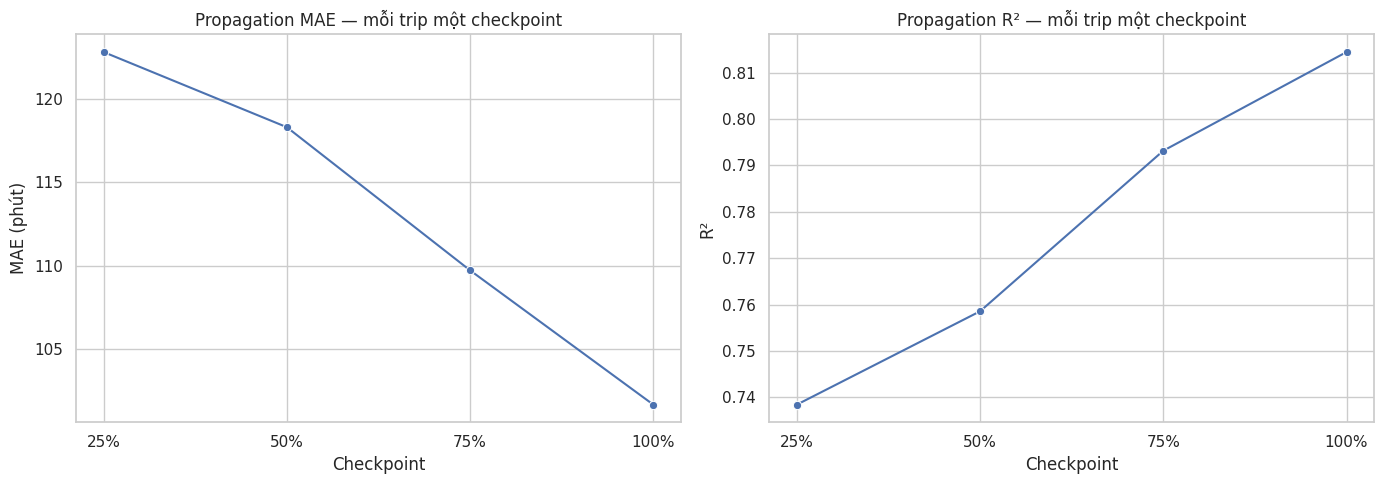

In [29]:
def select_one_checkpoint_per_trip(frame, target_progress):
    """Chọn checkpoint gần target progress nhất; mỗi trip đúng một dòng."""
    distance = (frame['progress_ratio'] - target_progress).abs()
    selected_index = distance.groupby(frame['trip_uuid']).idxmin()
    return selected_index

checkpoint_results = []
checkpoint_predictions = {}
for target_progress, label in [
    (0.25, '25%'),
    (0.50, '50%'),
    (0.75, '75%'),
    (1.00, '100%'),
]:
    selected_index = select_one_checkpoint_per_trip(stage_test, target_progress)
    selected = stage_test.loc[selected_index]
    selected_pred = propagation_pred_series.loc[selected_index].to_numpy()
    checkpoint_predictions[label] = (selected, selected_pred)

    checkpoint_results.append({
        'Checkpoint': label,
        'Trips': selected['trip_uuid'].nunique(),
        'Mean actual progress': selected['progress_ratio'].mean(),
        **regression_metrics(selected['final_delay_minutes'], selected_pred),
    })

checkpoint_results_df = pd.DataFrame(checkpoint_results)
display(checkpoint_results_df)

assert checkpoint_results_df['Trips'].max() <= stage_test['trip_uuid'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=checkpoint_results_df, x='Checkpoint', y='MAE', marker='o', ax=axes[0], color='C0')
axes[0].set_title('Propagation MAE — mỗi trip một checkpoint')
axes[0].set_ylabel('MAE (phút)')

sns.lineplot(data=checkpoint_results_df, x='Checkpoint', y='R2', marker='o', ax=axes[1], color='C0')
axes[1].set_title('Propagation R² — mỗi trip một checkpoint')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

## 13. Explainability with SHAP


SHAP is used at two levels:

1. **Start-of-trip ETA model**: explains which planned factors increase or decrease the predicted duration/ETA. Delay magnitude is derived from the same prediction.
2. **Propagation model**: explains how the observed stage delay and cumulative delay affect the final proxy delay.

Actual/end-time columns do not appear in the start-of-trip SHAP analysis.


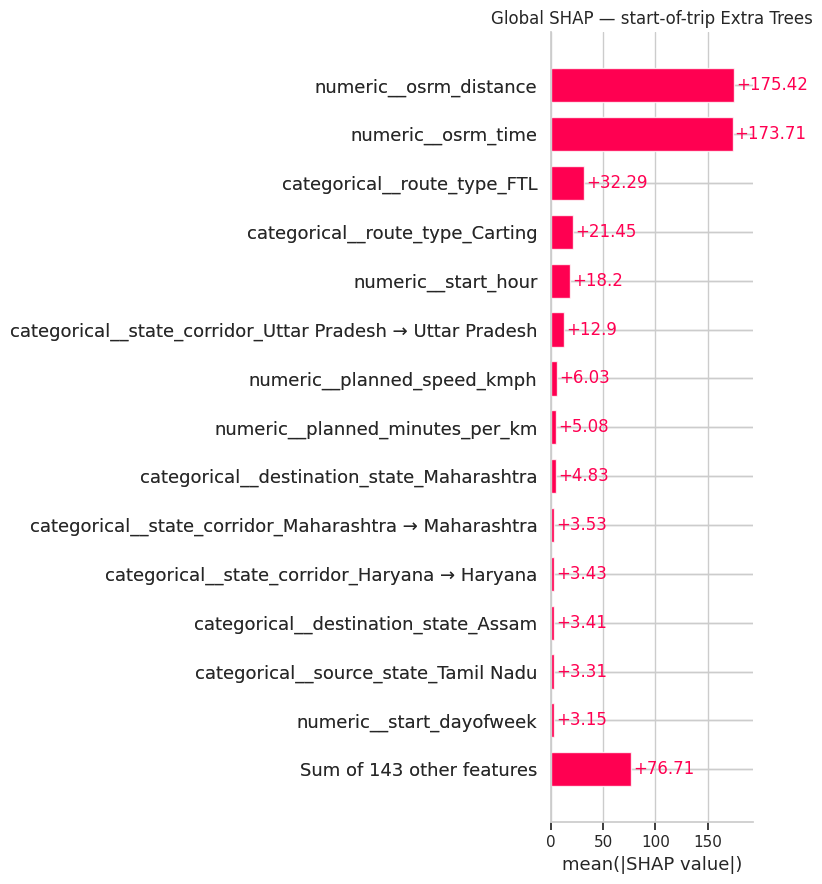

In [30]:
SHAP_SAMPLE_SIZE = min(400, X_test_t.shape[0])
shap_indices = np.random.default_rng(RANDOM_STATE).choice(
    X_test_t.shape[0], size=SHAP_SAMPLE_SIZE, replace=False
)
X_shap = X_test_t[shap_indices]
if hasattr(X_shap, 'toarray'):
    X_shap = X_shap.toarray()

TREE_EXPLAINER_MODELS = {
    'Decision Tree', 'Random Forest', 'Extra Trees', 'XGBoost'
}

if best_eta_model_name in TREE_EXPLAINER_MODELS:
    explainer_eta = shap.TreeExplainer(final_eta_model)
    shap_values_eta = explainer_eta(X_shap)
elif best_eta_model_name == 'Ridge':
    explainer_eta = shap.LinearExplainer(final_eta_model, X_shap)
    shap_values_eta = explainer_eta(X_shap)
else:
    background_size = min(100, X_shap.shape[0])
    background = shap.sample(X_shap, background_size, random_state=RANDOM_STATE)
    explainer_eta = shap.Explainer(
        final_eta_model.predict,
        background,
        feature_names=list(feature_names),
    )
    shap_values_eta = explainer_eta(X_shap)

shap_values_eta.feature_names = list(feature_names)

shap.plots.bar(shap_values_eta, max_display=15, show=False)
plt.title(f'Global SHAP — start-of-trip {best_eta_model_name}')
plt.tight_layout()
plt.show()


Shipment được giải thích:


,trip_uuid,source_name,destination_name,route_type,osrm_time,trip_duration_minutes,delay_minutes
13600,trip-153843695443252828,Pappadahandi_Central_DPP_2 (Orissa),Visakhapatnam_Gajuwaka_IP (Andhra Pradesh),Carting,211.000,"7,898.552","7,687.552"


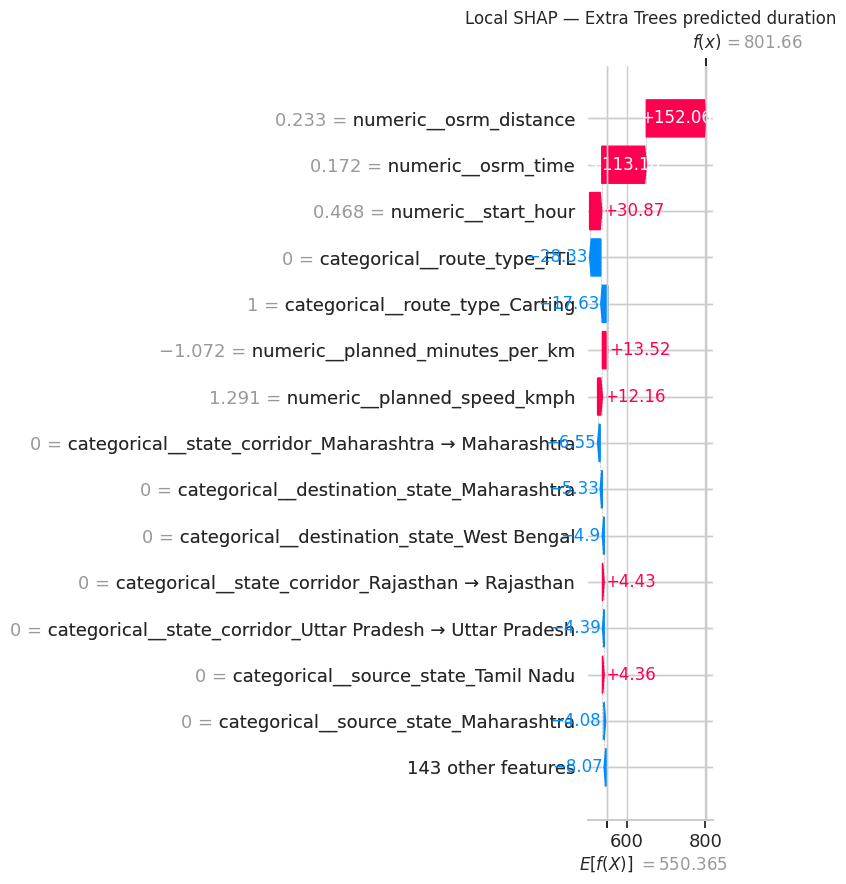

In [31]:
local_position = int(np.argmax(y_test_delay.to_numpy()))
X_local = X_test_t[local_position:local_position + 1]
if hasattr(X_local, 'toarray'):
    X_local = X_local.toarray()

local_shap = explainer_eta(X_local)
local_shap.feature_names = list(feature_names)

print('Shipment được giải thích:')
display(test_df.iloc[[local_position]][[
    'trip_uuid', 'source_name', 'destination_name', 'route_type',
    'osrm_time', 'trip_duration_minutes', 'delay_minutes'
]])

shap.plots.waterfall(local_shap[0], max_display=15, show=False)
plt.title(f'Local SHAP — {best_eta_model_name} predicted duration')
plt.tight_layout()
plt.show()


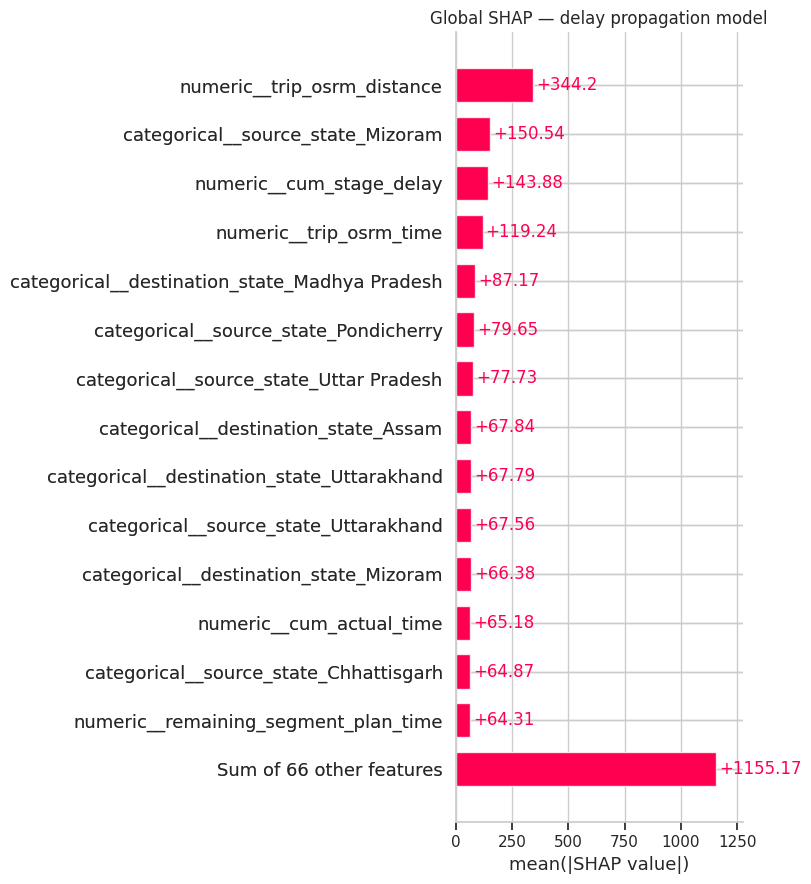

In [32]:
PROP_SHAP_SAMPLE_SIZE = min(400, X_stage_test_t.shape[0])
prop_indices = np.random.default_rng(RANDOM_STATE + 1).choice(
    X_stage_test_t.shape[0], size=PROP_SHAP_SAMPLE_SIZE, replace=False
)
X_prop_shap = X_stage_test_t[prop_indices]
if hasattr(X_prop_shap, 'toarray'):
    X_prop_shap = X_prop_shap.toarray()

explainer_prop = shap.TreeExplainer(propagation_model)
shap_values_prop = explainer_prop(X_prop_shap)
shap_values_prop.feature_names = list(stage_feature_names)

shap.plots.bar(shap_values_prop, max_display=15, show=False)
plt.title('Global SHAP — delay propagation model')
plt.tight_layout()
plt.show()

## 14. Single-Shipment Prediction Example


In [33]:
def predict_trip_at_start(row):
    """Dự đoán duration, ETA, proxy delay và severe-delay probability cho một trip."""
    X_row = row[START_FEATURES].to_frame().T
    X_row_t = start_preprocessor.transform(X_row)

    predicted_duration = float(final_eta_model.predict(X_row_t)[0])
    predicted_delay = predicted_duration - float(row['osrm_time'])
    severe_probability = float(classifier.predict_proba(X_row_t)[0, 1])
    predicted_eta = row['trip_start_time'] + pd.to_timedelta(predicted_duration, unit='m')

    return pd.Series({
        'trip_uuid': row['trip_uuid'],
        'origin': row['source_name'],
        'destination': row['destination_name'],
        'selected ETA model': best_eta_model_name,
        'selected severe-delay classifier': best_classifier_name,
        'OSRM baseline minutes': row['osrm_time'],
        'Predicted full elapsed minutes': predicted_duration,
        'Predicted proxy delay minutes': predicted_delay,
        'Predicted ETA': predicted_eta,
        'Severe delay probability': severe_probability,
        'Classification probability threshold': best_classification_threshold,
        'Actual full elapsed minutes': row['trip_duration_minutes'],
        'Actual proxy delay minutes': row['delay_minutes'],
        'Actual ETA': row['actual_eta'],
    })

example_prediction = predict_trip_at_start(test_df.iloc[0])
display(example_prediction.to_frame('value'))


,value
trip_uuid,trip-153800653897073708
origin,Dhule_MIDCAvdn_I (Maharashtra)
destination,Chalisgaon_BhadgDPP_D (Maharashtra)
selected ETA model,Extra Trees
selected severe-delay classifier,Extra Trees
OSRM baseline minutes,41.000
Predicted full elapsed minutes,181.191
Predicted proxy delay minutes,140.191
Predicted ETA,2018-09-27 03:03:30.429495222
Severe delay probability,0.351


## 15. Model Export and Conclusion


In [34]:
SAVE_ARTIFACTS = True

if SAVE_ARTIFACTS:
    artifact_dir = Path('/kaggle/working/artifacts') if Path('/kaggle/working').exists() else Path('artifacts')
    artifact_dir.mkdir(exist_ok=True, parents=True)

    joblib.dump(start_preprocessor, artifact_dir / 'start_preprocessor.joblib')
    joblib.dump(final_eta_model, artifact_dir / 'eta_model.joblib')
    joblib.dump(classifier, artifact_dir / 'severe_delay_classifier.joblib')
    joblib.dump(stage_preprocessor, artifact_dir / 'stage_preprocessor.joblib')
    joblib.dump(propagation_model, artifact_dir / 'delay_propagation_model.joblib')

    eta_validation_results_df.to_csv(
        artifact_dir / 'eta_validation_leaderboard.csv', index=False
    )
    eta_test_results_df.to_csv(
        artifact_dir / 'eta_final_test_results.csv', index=False
    )
    classifier_validation_results_df.to_csv(
        artifact_dir / 'classifier_validation_leaderboard.csv', index=False
    )
    classification_metrics.to_csv(
        artifact_dir / 'classifier_final_test_results.csv', index=False
    )

    metadata = {
        'ground_truth_duration': 'trip_end_time - trip_start_time',
        'delay_definition': 'trip_duration_minutes - osrm_time',
        'delay_threshold_minutes': DELAY_THRESHOLD_MINUTES,
        'classification_probability_threshold': best_classification_threshold,
        'start_features': START_FEATURES,
        'stage_features': STAGE_FEATURES,
        'eta_candidate_models': ETA_MODEL_NAMES,
        'classifier_candidate_models': CLASSIFIER_MODEL_NAMES,
        'selected_eta_model_from_validation': str(best_eta_model_name),
        'selected_classifier_from_validation': str(best_classifier_name),
        'external_train_trips': int(len(train_df)),
        'final_test_trips': int(len(test_df)),
    }
    (artifact_dir / 'metadata.json').write_text(
        json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8'
    )
    print(f'Đã lưu artifacts tại: {artifact_dir.resolve()}')
else:
    print('SAVE_ARTIFACTS=False — đổi thành True để lưu model vào /kaggle/working/artifacts.')


Đã lưu artifacts tại: /kaggle/working/artifacts


### Conclusion

The notebook builds four consistent outputs:

1. **Final ETA regression** using the ground truth `trip_end_time`, choosing between Ridge and five tree models.
2. **Delay magnitude** derived from the same ETA model, with no algebraic inconsistency.
3. **Delay probability** comparing five tree classifiers, each with its own probability threshold chosen on validation.
4. **Delay propagation** updating the final delay at 25%, 50%, 75%, and 100% progress, one observation per trip.

### Models Added

- Decision Tree Regressor / Classifier;
- Random Forest Regressor / Classifier;
- Extra Trees Regressor / Classifier;
- AdaBoost Regressor / Classifier;
- XGBoost Regressor / Classifier;
- Ridge is retained as a non-tree baseline for ETA.

### Methodological Pitfalls Avoided

- No random per-segment split; train/test never share a `trip_uuid`.
- `actual_time` is not used as the final elapsed duration.
- The model is not selected using the final test set.
- Segment totals, leg count, or checkpoint count are not used at start-of-trip.
- Mixed timestamps are parsed fully.
- Checkpoints are sorted by `cutoff_timestamp`, not by `actual_time`.
- Planned segment times equal to zero are excluded.
- `total_stages` is excluded from the propagation feature set.
- Training weights are balanced across trips with different numbers of checkpoints.
- Row-level propagation scores are not reported as the primary metric.
- The classification probability threshold is chosen separately for each model on validation.

### Limitations to Note in the Report

- `osrm_time` is only a routing baseline/proxy schedule, not the official delivery SLA.
- The total planned segment time is assumed to be available in the route plan when computing progress.
- The dataset does not include direct weather, traffic, congestion, or customs data.
- The dataset has a high severe-delay rate under the 120-minute proxy threshold; this should be replaced with the real SLA in production.
- The dataset reflects September–October 2018 data; drift should be checked before deployment.
